In [109]:
!apt install libgraphviz-dev
!pip install pygraphviz


'apt' is not recognized as an internal or external command,
operable program or batch file.


  Using cached pygraphviz-1.11.zip (120 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Failed to build pygraphviz


  error: subprocess-exited-with-error
  
  exit code: 1
  
  [54 lines of output]
  running bdist_wheel
  running build
  running build_py
  creating build
  creating build\lib.win-amd64-cpython-310
  creating build\lib.win-amd64-cpython-310\pygraphviz
  copying pygraphviz\agraph.py -> build\lib.win-amd64-cpython-310\pygraphviz
  copying pygraphviz\graphviz.py -> build\lib.win-amd64-cpython-310\pygraphviz
  copying pygraphviz\scraper.py -> build\lib.win-amd64-cpython-310\pygraphviz
  copying pygraphviz\testing.py -> build\lib.win-amd64-cpython-310\pygraphviz
  copying pygraphviz\__init__.py -> build\lib.win-amd64-cpython-310\pygraphviz
  creating build\lib.win-amd64-cpython-310\pygraphviz\tests
  copying pygraphviz\tests\test_attribute_defaults.py -> build\lib.win-amd64-cpython-310\pygraphviz\tests
  copying pygraphviz\tests\test_clear.py -> build\lib.win-amd64-cpython-310\pygraphviz\tests
  copying pygraphviz\tests\test_close.py -> build\lib.win-amd64-cpython-310\pygraphviz\tests
  co

In [1]:
import os, sys
from pathlib import Path

cur_dir = os.getcwd()
path = Path(cur_dir)
sys.path.insert(0, str(path.parent.absolute()))

import pandas as pd
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pickle

from src.preprocess import preprocess_df
from src.network_connectivity import ConnectivityUnit
from src.kalman_network_tools import graphs_2_risk_scores
from src.network_plotting import risks_over_time_2d, risks_over_time_3d

In [2]:
file_addr = '..\CIC-IDS-2017\GeneratedLabelledFlows\TrafficLabelling\Monday-WorkingHours.pcap_ISCX.csv' 
df_cic = pd.read_csv(file_addr, header=0, encoding='cp1252')

df = preprocess_df(df_cic, date_col=' Timestamp')
print(df.shape)

(529481, 85)


In [4]:
import pickle

with open(r'saves\sample_nodes.pickle', 'rb') as handle: # samp_nodes
    samp_names = pickle.load(handle)

In [6]:
samp_names

['192.168.10.15',
 '192.168.10.9',
 '173.194.206.108',
 '131.253.61.66',
 '91.189.88.161',
 '192.168.10.17',
 '131.253.61.82',
 '134.170.51.247',
 '40.77.226.220',
 '192.168.10.50',
 '192.168.10.16',
 '209.48.71.168',
 '23.61.187.27',
 '192.168.10.3',
 '192.168.10.8',
 '192.168.10.14',
 '192.168.10.12']

In [5]:
# Pick the certain connections

NUM_CONN = 200 # 200
N = 8110 # 5010, 8110, 21710

print(df.shape)
df = df.iloc[:NUM_CONN, :]

(529481, 85)


In [9]:
import pygraphviz as pgv
from networkx.drawing.nx_agraph import graphviz_layout, to_agraph

# set defaults
g=nx.from_pandas_edgelist(df, ' Source IP', ' Destination IP')
g.graph['graph']={'labeljust':1, 'margin':0, 'ratio':'fill', 'size':'8, 5.4'}
g.graph['node']={'shape':'doublecircle', 'color': "#8DFF1D", 'style': 'filled',
                'fontsize': 12, 'fixedsize':True, 'width': 0.40, 'height':0.40}
#g.graph['edges']={'arrowsize':'4.0'}

A = to_agraph(g)
#print(A)
A.layout('twopi')
node_list = ['157.240.18.19', '13.58.175.81', '209.197.3.65', '213.174.132.66',
            '172.217.10.34', '52.84.145.181', '31.13.71.36']
for i, node in enumerate(A.iternodes()):
    if node.name == '192.168.10.12': # '192.168.10.3'
        node.attr['color'] = '#364D1F'
        node.attr['shape'] = 'ellipse'
        node.attr['width'] = 0.8
        node.attr['height'] = 0.6
        node.attr['label'] = '<<TABLE BORDER="0"><TR><TD></TD></TR><TR><TD BGCOLOR="#FFFFFF">CIC-IDS-2017</TD></TR></TABLE>>'

    elif node.name == '203.133.166.24' or node.name == '204.237.173.26':
        node.attr['color'] = 'blue'
    """elif node.name in node_list:
        node.attr['color'] = 'firebrick1'    """

A.draw(r'figures\network2_highlighted.png')

ModuleNotFoundError: No module named 'pygraphviz'

Custom

In [ ]:
list(g.nodes)

In [ ]:
# Pick the certain connections

NUM_CONN = 400 # 200
N = 21710 # 5010, 8110, 21710

df0 = DF.copy()
df0.loc[:,date_feature] = pd.to_datetime(df0[date_feature])
df0 = df0.sort_values(by=[date_feature])
df = df0.iloc[N:,:].copy()

#df = df[df[df.columns[1]].isin(samp_names)].copy()
#df = df[df[df.columns[3]].isin(samp_names)].copy()

print(df.shape)
df = df.iloc[:NUM_CONN, :]

import pygraphviz as pgv
from networkx.drawing.nx_agraph import graphviz_layout, to_agraph

# set defaults
g=nx.from_pandas_edgelist(df, ' Source IP', ' Destination IP')
g.remove_edge('192.168.10.3', '192.168.10.9')
g.add_edge('192.168.10.3', '192.168.10.19')
g.remove_nodes_from(['216.200.232.172', '192.168.10.5', '54.192.37.69',
                     '8.0.6.4', '8.6.0.1', '195.234.240.81', '192.168.10.51'])

g.graph['graph']={'labeljust':1, 'margin':0, 'ratio':'fill', 'size':'8, 5.4'}
g.graph['node']={'shape':'doublecircle', 'color': "#8DFF1D", 'style': 'filled',
                'fontsize': 18, 'fixedsize':True, 'width': 0.40, 'height':0.40}
#g.graph['edges']={'arrowsize':'4.0'}

A = to_agraph(g)
#print(A)
A.layout('twopi')
node_list = ['192.168.10.1', '184.173.85.152', '192.243.250.58', '93.184.216.180',
            '98.139.225.43', '54.192.37.14', '172.217.10.46']
for i, node in enumerate(A.iternodes()):
    if node.name == '172.217.6.226': # '192.168.10.3'
        node.attr['color'] = '#364D1F'
        node.attr['shape'] = 'ellipse'
        node.attr['width'] = 0.8
        node.attr['height'] = 0.6
        node.attr['label'] = '<<TABLE BORDER="0"><TR><TD></TD></TR><TR><TD BGCOLOR="#FFFFFF">CIC-IDS-2017</TD></TR></TABLE>>'

    elif node.name == '198.105.244.11' or node.name == '52.23.3.197':
        node.attr['color'] = 'blue'
    elif node.name in node_list:
        node.attr['color'] = 'firebrick1'

A.draw('network3_route.png')

(508208, 84)


In [ ]:
#nodes = list(g.nodes)
#keep_nodes = ['192.168.10.25', '192.168.10.17', '192.168.10.3', '192.168.10.1', '192.168.10.14',
#              '192.168.10.19', '172.217.6.226', '192.168.10.9', '72.21.91.29']

def sub_sample_nodes(nodes, p, keep_nodes, seed= 31):
    "Discards about 1-p percent of the nodes while maintanining keep_nodes"
    new_nodes = keep_nodes.copy()
    temp_nodes = nodes.copy()
    [temp_nodes.remove(x) for x in keep_nodes]

    np.random.seed(seed)
    rand_perm = np.random.permutation(np.arange(len(temp_nodes)))
    rand_perm = rand_perm[:int(len(temp_nodes)*p)]
    new_nodes.extend(list(np.array(temp_nodes)[rand_perm] ))
    return new_nodes

#len(sub_sample_nodes(nodes, 0.5, keep_nodes, seed= 31)), len(nodes)

In [ ]:
g.subgraph(sub_sample_nodes(nodes, 0.5, keep_nodes, seed= 31))

In [ ]:
# Pick the certain connections

NUM_CONN = 400 # 200
N = 21710 # 5010, 8110, 21710

df0 = DF.copy()
df0.loc[:,date_feature] = pd.to_datetime(df0[date_feature])
df0 = df0.sort_values(by=[date_feature])
df = df0.iloc[N:,:].copy()

#df = df[df[df.columns[1]].isin(samp_names)].copy()
#df = df[df[df.columns[3]].isin(samp_names)].copy()

print(df.shape)
df = df.iloc[:NUM_CONN, :]

import pygraphviz as pgv
from networkx.drawing.nx_agraph import graphviz_layout, to_agraph

# set defaults
g=nx.from_pandas_edgelist(df, ' Source IP', ' Destination IP')
g.remove_edge('192.168.10.3', '192.168.10.9')
g.add_edge('192.168.10.3', '192.168.10.19')
g.remove_nodes_from(['216.200.232.172', '192.168.10.5', '54.192.37.69',
                     '8.0.6.4', '8.6.0.1', '195.234.240.81', '192.168.10.51'])

# Sub-sample nodes
nodes = list(g.nodes)
keep_nodes = ['192.168.10.25', '192.168.10.17', '192.168.10.3', '192.168.10.1', '192.168.10.14',
              '192.168.10.19', '172.217.6.226', '192.168.10.9', '72.21.91.29']
g = g.subgraph(sub_sample_nodes(nodes, 0.5, keep_nodes, seed= 31))


g.graph['graph']={'labeljust':1, 'margin':0, 'ratio':'fill', 'size':'16, 10'} #'size':'8, 5.4'
g.graph['node']={'shape':'doublecircle', 'color': "#b0b0b0", 'style': 'filled',
                'fontsize': 18, 'fixedsize':True, 'width': 0.60, 'height':0.60}# 'width': 0.40, 'height':0.40
#g.graph['edges']={'arrowsize':'4.0'}
# #70706f

A = to_agraph(g)
#print(A)
A.layout('twopi')
risky_nodes = ['172.217.6.225', '68.67.178.176', '192.243.250.58', '93.184.216.180',
            '98.139.225.43', '54.192.37.14', '172.217.10.46', '54.229.179.123']
safe_nodes = ['63.140.56.141', '124.33.183.215', '54.250.123.68', '23.50.75.27', '198.232.125.123']

for i, node in enumerate(A.iternodes()):
    #node.attr['xlabel'] = str(node)
    #node.attr['xlp'] = '0, 0'
    node.attr['label'] = ''
    if node.name == '172.217.6.226': # '192.168.10.3'
        node.attr['color'] = '#33240a'
        node.attr['shape'] = 'ellipse'
        node.attr['width'] = 2.3 #0.8
        node.attr['height'] = 0.8 #0.6
        node.attr['fontcolor'] = '#FFFFFF'
        node.attr['label'] = 'A Network\nof Devices'#'<<TABLE BORDER="0"><TR><TD></TD></TR><TR><TD BGCOLOR="#33240a">An Enterprise<BR/>Network Topology</TD></TR></TABLE>>'
        node.attr['fontname'] = 'times bold'

    elif node.name == '198.105.244.11' or node.name == '52.23.3.197':
        node.attr['color'] = 'royalblue'
        #node.attr['xlabel'] = 'Entity 1' if node.name == '198.105.244.11' else 'Entity 2'
    elif node.name in risky_nodes:
        node.attr['color'] = 'firebrick1'#'firebrick1'
    elif node.name in safe_nodes:
        node.attr['color'] = '#3b6b0c'#'firebrick1'

A.draw('network3_route_2.png')

<ipython-input-10-c699d021b20b>:7: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  df0.loc[:,date_feature] = pd.to_datetime(df0[date_feature])


(508208, 84)


/usr/local/lib/python3.9/dist-packages/pygraphviz/agraph.py:1405: RuntimeWarning: Warning: node '192.168.10.19', graph '' size too small for label

  warnings.warn(b"".join(errors).decode(self.encoding), RuntimeWarning)


In [ ]:
g.nodes

NodeView(('192.168.10.19', '52.206.227.49', '172.217.6.226', '54.229.179.123', '74.217.253.90', '192.168.10.3', '192.168.10.1', '192.168.10.14', '198.232.125.123', '54.192.37.14', '23.194.109.177', '72.21.91.29', '104.16.25.216', '192.168.10.25', '172.217.11.14', '198.105.244.11', '23.50.75.27', '172.217.10.46', '192.168.10.17', '74.217.253.61', '54.192.36.242', '72.167.239.239', '172.217.6.225', '192.168.10.9', '54.250.123.68', '62.138.155.102', '52.38.5.243', '182.22.65.140', '124.33.183.215', '52.0.223.109', '54.171.192.108', '63.140.56.141', '68.67.178.246', '52.23.3.197', '68.67.178.176', '184.173.85.152'))

In [ ]:
list(A.graph_attr)

['bb', 'labeljust', 'margin', 'ratio', 'size']

In [ ]:
list(A.node_attr)

['color',
 'fixedsize',
 'fontsize',
 'height',
 'label',
 'pos',
 'shape',
 'style',
 'width',
 'xlabel']

In [ ]:
A.node_attr['label']

'\\N'

In [ ]:
A.graph_attr['size'] = '16, 11'

'8, 5.4'

(500, 84)


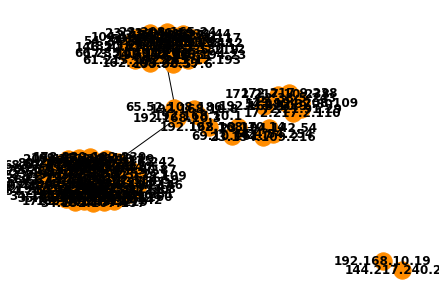

In [ ]:
print(df.shape)
g=nx.from_pandas_edgelist(df, ' Source IP', ' Destination IP')

plt.figure(figsize=(6,4))
my_pos = nx.spring_layout(g, seed = 1234) # 1234
nx.draw(g, pos= my_pos, with_labels=True, node_color = 'darkorange', font_weight='bold')

In [ ]:
node.attr['label']

'\\N'

In [ ]:
print(A)

strict graph "" {
	graph [bb="0,0,576,389",
		labeljust=1,
		margin=0,
		ratio=fill,
		size="8, 5.4"
	];
	node [color="#8DFF1D",
		fixedsize=True,
		fontsize=12,
		height=0.4,
		label="\N",
		shape=doublecircle,
		style=filled,
		width=0.4
	];
	"192.168.10.25"	 [height=0.51389,
		pos="264.1,108.32",
		width=0.51389];
	"157.240.18.19"	 [height=0.51389,
		pos="350.25,111.43",
		width=0.51389];
	"192.168.10.25" -- "157.240.18.19"	 [pos="282.79,109 297.24,109.52 317.15,110.24 331.59,110.76"];
	"192.168.10.3"	 [height=0.51389,
		pos="274.96,193.83",
		width=0.51389];
	"192.168.10.25" -- "192.168.10.3"	 [pos="266.45,126.88 268.28,141.22 270.79,160.98 272.61,175.31"];
	"169.45.253.37"	 [height=0.51389,
		pos="181.46,132.88",
		width=0.51389];
	"192.168.10.25" -- "169.45.253.37"	 [pos="246.16,113.65 232.3,117.77 213.21,123.44 199.36,127.56"];
	"68.67.178.252"	 [height=0.51389,
		pos="179.9,126.85",
		width=0.51389];
	"192.168.10.25" -- "68.67.178.252"	 [pos="245.83,112.34 231.7,115.45 212.25,1

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

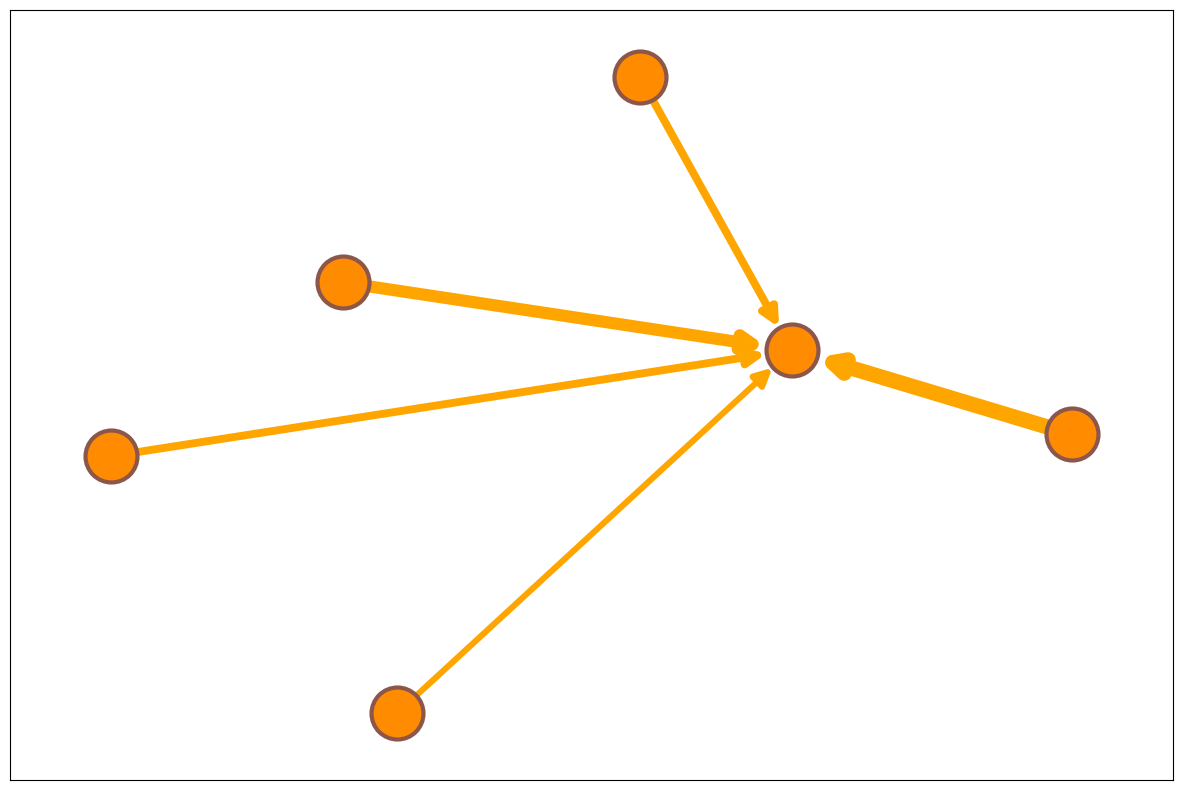

In [2]:
g = nx.DiGraph()
g.add_edges_from([ (2, 1, {'weight':0.5}),
                  (3, 1, {'weight':1.2}), (4, 1, {'weight':1.9}),
                  (6, 1, {'weight':0.3}), (5, 1, {'weight':0.5})])

plt.figure(figsize=(15, 10))
my_pos = nx.spring_layout(g, seed = 34) # 82
widths = [8*np.sqrt(g[u][v]['weight']) for u,v in g.edges]

nodes = nx.draw_networkx_nodes(g, my_pos,  node_color = 'darkorange', node_size= 1400 )
nodes.set_edgecolor('tab:brown')
nodes.set_linewidth(3)
#nx.draw_networkx_labels(g, my_pos, font_weight='bold')
nx.draw_networkx_edges(g, my_pos, width= widths, connectionstyle='arc3,rad=-0', arrowsize= 25, node_size= 1400, edge_color= 'orange' )


#nx.draw(g, pos=my_pos,  with_labels=False,  font_weight='bold', node_color = 'darkorange',
#        width= widths, connectionstyle='arc3,rad=-0.2', node_size= 700, arrowsize= 15)


In [8]:
np.random.rand()

0.9308773124388499

In [111]:
import pygraphviz

seed = 31 # 31
np.random.seed(seed)
g = nx.erdos_renyi_graph(100, 0.005, seed=seed, directed=True)
#g = nx.full_rary_tree(3, 32, create_using=nx.DiGraph)
g = g.reverse()
for (u, v) in g.edges():
    g.edges[u,v]['weight'] = 1 + (np.random.rand() * .0) 
gcc = sorted(nx.connected_components(g.to_undirected()), key=len, reverse=True)
g = g.subgraph(gcc[0])

seed_layout += 1
#seed_layout = 97
plt.figure(figsize=(15, 10))
my_pos = nx.spring_layout(g, seed = seed_layout) # 82
#my_pos = nx.random_layout(g, seed = seed_layout)
my_pos = nx.nx_agraph.graphviz_layout(g, prog="dot")
widths = [ 3 * (g[u][v]['weight']) ** (1) for u,v in g.edges]

nodes = nx.draw_networkx_nodes(g, my_pos,  node_color = 'darkorange', node_size= 640 ) # 1400
nodes.set_edgecolor('tab:brown')
nodes.set_linewidth(3)
nx.draw_networkx_edges(g, my_pos, width= widths, connectionstyle='arc3,rad=-0', arrowsize= 25, node_size= 1400, edge_color= 'orange' )
seed_layout

ModuleNotFoundError: No module named 'pygraphviz'